# Waiting List EDA

Answers four questions using the NTPF (National Treatment Purchase Fund,
Ireland) sample in `data/processed/`:

1. Which specialties have the longest waits?
2. How do adult and child waiting lists compare?
3. What's the trend over the period loaded?
4. What's the gap between Inpatient/Day Case and Outpatient?

**Data note:** the specialty-level rows (`All_Data.csv`) are a real
snapshot transcribed from NTPF's own published national summary reports
(Inpatient/Day Case as at 31 Aug 2023, Outpatient as at 27 Jul 2023) - see
`etl/build_sample_from_ntpf_published_reports.py` for sources. The trend and
IP-vs-OP questions use `National_Monthly_Totals.csv`, a real multi-month
series (Oct 2024-Sep 2025) from NTPF's monthly press releases. Once you run
`etl/combine_waiting_lists.py` against your own full multi-year download,
re-run this notebook against the richer dataset - the code doesn't change.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 20)

all_data = pd.read_csv("../data/processed/All_Data.csv")
national = pd.read_csv("../data/processed/National_Monthly_Totals.csv", parse_dates=["Archive_Date"])

# Weight each time band by its midpoint (months) to get a comparable wait estimate
MIDPOINTS = {"0-6 Months": 3, "6-12 Months": 9, "12-18 Months": 15, "18+ Months": 24}
all_data["Midpoint_Months"] = all_data["Time_Bands"].map(MIDPOINTS)

all_data.head()

,Archive_Date,Specialty_HIPE,Specialty_Name,Case_Type,Adult_Child,Age_Profile,Time_Bands,Total,Source_Name,Specialty_Group,Midpoint_Months
0,2023-08-31,NaN,Anaesthetics,Inpatient/Day Case,Adult,All Ages,0-6 Months,88,"NTPF National02.pdf (in-patient, Aug 2023)",Respiratory,3
1,2023-08-31,NaN,Anaesthetics,Inpatient/Day Case,Adult,All Ages,6-12 Months,2,"NTPF National02.pdf (in-patient, Aug 2023)",Respiratory,9
2,2023-08-31,NaN,Anaesthetics,Inpatient/Day Case,Adult,All Ages,12-18 Months,0,"NTPF National02.pdf (in-patient, Aug 2023)",Respiratory,15
3,2023-08-31,NaN,Anaesthetics,Inpatient/Day Case,Adult,All Ages,18+ Months,0,"NTPF National02.pdf (in-patient, Aug 2023)",Respiratory,24
4,2023-08-31,NaN,Breast Surgery,Inpatient/Day Case,Adult,All Ages,0-6 Months,107,"NTPF National02.pdf (in-patient, Aug 2023)",Other,3


## 1. Which specialties have the longest waits?

Weighted average wait (months) = sum(patients in band x band midpoint) / total patients, per specialty.

In [2]:
specialty_wait = (
    all_data.groupby("Specialty_Name")
    .apply(lambda g: (g["Total"] * g["Midpoint_Months"]).sum() / g["Total"].sum())
    .sort_values(ascending=False)
)
specialty_totals = all_data.groupby("Specialty_Name")["Total"].sum()

# Focus on specialties with a meaningful number of patients (>200) so small-sample
# specialties don't dominate the "longest wait" ranking
longest_waits = specialty_wait[specialty_totals >= 200].head(10)
longest_waits

Specialty_Name
Developmental Paediatrics      12.149864
Maxillo-Facial                 11.895204
Clinical (Medical) Genetics    10.982096
Endocrinology                  10.806012
Clinical Neurophysiology       10.781682
Gastro-Intestinal Surgery       8.793792
Dermatology                     8.350370
Plastic Surgery                 8.313895
General Medicine                8.160256
Rheumatology                    8.130183
dtype: float64

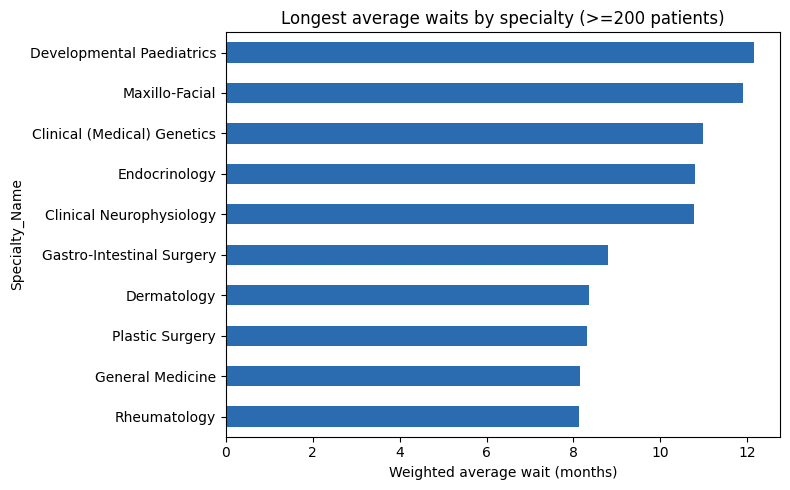

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
longest_waits.sort_values().plot.barh(ax=ax, color="#2b6cb0")
ax.set_xlabel("Weighted average wait (months)")
ax.set_title("Longest average waits by specialty (>=200 patients)")
plt.tight_layout()
plt.savefig("../docs/img/longest_waits_by_specialty.png", dpi=120)
plt.show()

**Finding:** Developmental Paediatrics, Maxillo-Facial and Clinical (Medical) Genetics show the longest weighted average waits (~11-12 months) among specialties with meaningful volume, with Endocrinology and Clinical Neurophysiology close behind - all Outpatient specialties, where the 18+ month band carries relatively more patients than in Inpatient/Day Case.

## 2. Adult vs Child comparison

In [4]:
adult_child = all_data.groupby("Adult_Child")["Total"].sum()
adult_child_wait = (
    all_data.groupby("Adult_Child")
    .apply(lambda g: (g["Total"] * g["Midpoint_Months"]).sum() / g["Total"].sum())
)
comparison = pd.DataFrame({"Total_Patients": adult_child, "Weighted_Avg_Wait_Months": adult_child_wait})
comparison

,Total_Patients,Weighted_Avg_Wait_Months
Adult_Child,,
Adult,381170,7.395614
Child,16491,8.807168


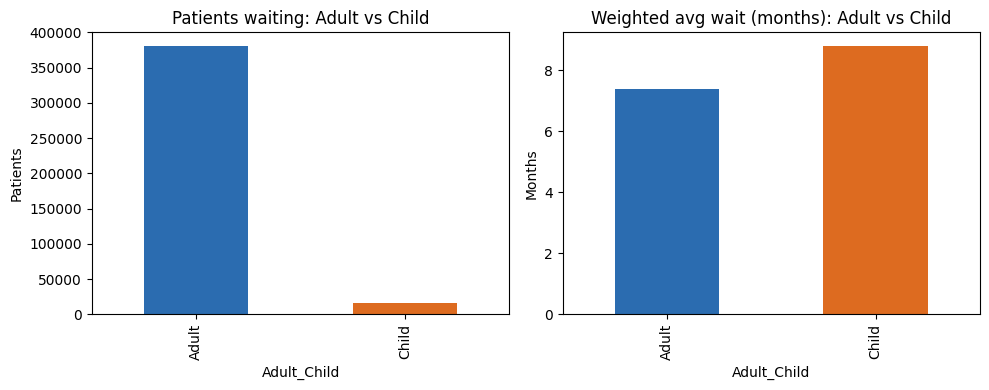

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
adult_child.plot.bar(ax=ax[0], color=["#2b6cb0", "#dd6b20"])
ax[0].set_title("Patients waiting: Adult vs Child")
ax[0].set_ylabel("Patients")

adult_child_wait.plot.bar(ax=ax[1], color=["#2b6cb0", "#dd6b20"])
ax[1].set_title("Weighted avg wait (months): Adult vs Child")
ax[1].set_ylabel("Months")
plt.tight_layout()
plt.savefig("../docs/img/adult_vs_child.png", dpi=120)
plt.show()

**Finding:** adults make up 96% of patients in this sample (381,170 vs 16,491), but the weighted average wait is *longer* for children (8.8 months) than adults (7.4 months). That's worth treating cautiously rather than as a general claim - the child rows here only cover a subset of specialties (the ones NTPF's published summary broke out separately), so this could reflect which specialties are represented rather than a true adult/child gap. The full multi-year download would settle it.

## 3. Trend over the period loaded

Using `National_Monthly_Totals.csv` - a real multi-month series from NTPF's press releases (specialty-level data here is only a single snapshot, not a time series).

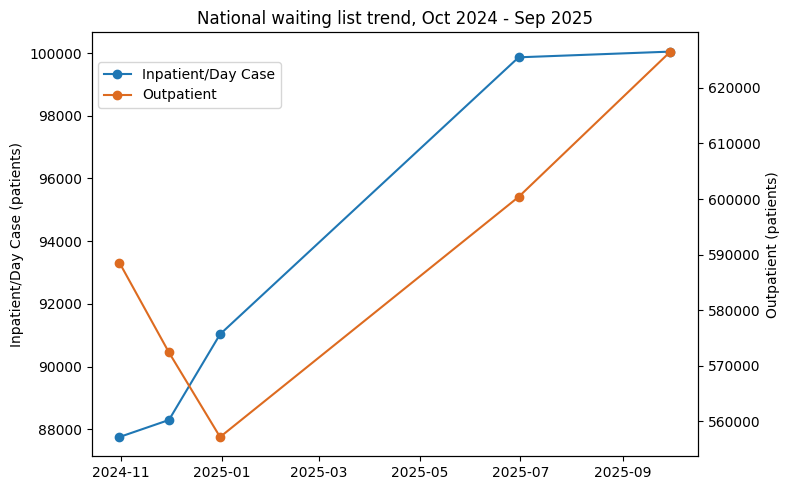

In [6]:
ipdc_trend = national[national["Case_Type"] == "Inpatient/Day Case"].sort_values("Archive_Date")
op_trend = national[national["Case_Type"] == "Outpatient"].sort_values("Archive_Date")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ipdc_trend["Archive_Date"], ipdc_trend["Total"], marker="o", label="Inpatient/Day Case")
ax2 = ax.twinx()
ax2.plot(op_trend["Archive_Date"], op_trend["Total"], marker="o", color="#dd6b20", label="Outpatient")
ax.set_ylabel("Inpatient/Day Case (patients)")
ax2.set_ylabel("Outpatient (patients)")
ax.set_title("National waiting list trend, Oct 2024 - Sep 2025")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.savefig("../docs/img/national_trend.png", dpi=120)
plt.show()

In [7]:
ipdc_change = ipdc_trend.iloc[-1]["Total"] - ipdc_trend.iloc[0]["Total"]
op_change = op_trend.iloc[-1]["Total"] - op_trend.iloc[0]["Total"]
print(f"Inpatient/Day Case: {ipdc_trend.iloc[0]['Total']:,} -> {ipdc_trend.iloc[-1]['Total']:,} ({ipdc_change:+,})")
print(f"Outpatient:         {op_trend.iloc[0]['Total']:,} -> {op_trend.iloc[-1]['Total']:,} ({op_change:+,})")

Inpatient/Day Case: 87,753 -> 100,045 (+12,292)
Outpatient:         588,544 -> 626,521 (+37,977)


**Finding:** over Oct 2024-Sep 2025, the national Inpatient/Day Case list grew from 87,753 to 100,045 (+12,292, +14.0%), and Outpatient grew from 588,544 to 626,521 (+37,977, +6.5%). Both lists trended upward across the period rather than shrinking.

## 4. Inpatient vs Outpatient gap

In [8]:
latest_date = national["Archive_Date"].max()
latest = national[national["Archive_Date"] == latest_date].set_index("Case_Type")["Total"]
gap_ratio = latest["Outpatient"] / latest["Inpatient/Day Case"]
print(latest)
print(f"\nAs of {latest_date.date()}, the Outpatient list is {gap_ratio:.1f}x the size of the Inpatient/Day Case list.")

Case_Type
Inpatient/Day Case    100045
Outpatient            626521
GI Endoscopy           33784
Name: Total, dtype: int64

As of 2025-09-30, the Outpatient list is 6.3x the size of the Inpatient/Day Case list.


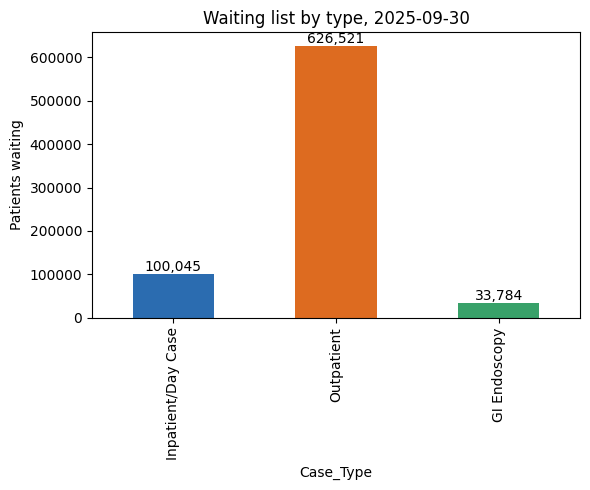

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
latest.plot.bar(ax=ax, color=["#2b6cb0", "#dd6b20", "#38a169"])
ax.set_ylabel("Patients waiting")
ax.set_title(f"Waiting list by type, {latest_date.date()}")
for i, v in enumerate(latest):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("../docs/img/ip_vs_op_gap.png", dpi=120)
plt.show()

**Finding:** Outpatient is consistently the dominant driver of the national total - 6.3x the size of the Inpatient/Day Case list as of Sep 2025 - so headline \"waiting list\" figures are mostly an Outpatient story, and any capacity intervention aimed only at Inpatient/Day Case addresses a small fraction of the overall backlog.